In [8]:
!pip install pandas scikit-learn matplotlib -q
print("Ready! ✅")


Ready! ✅


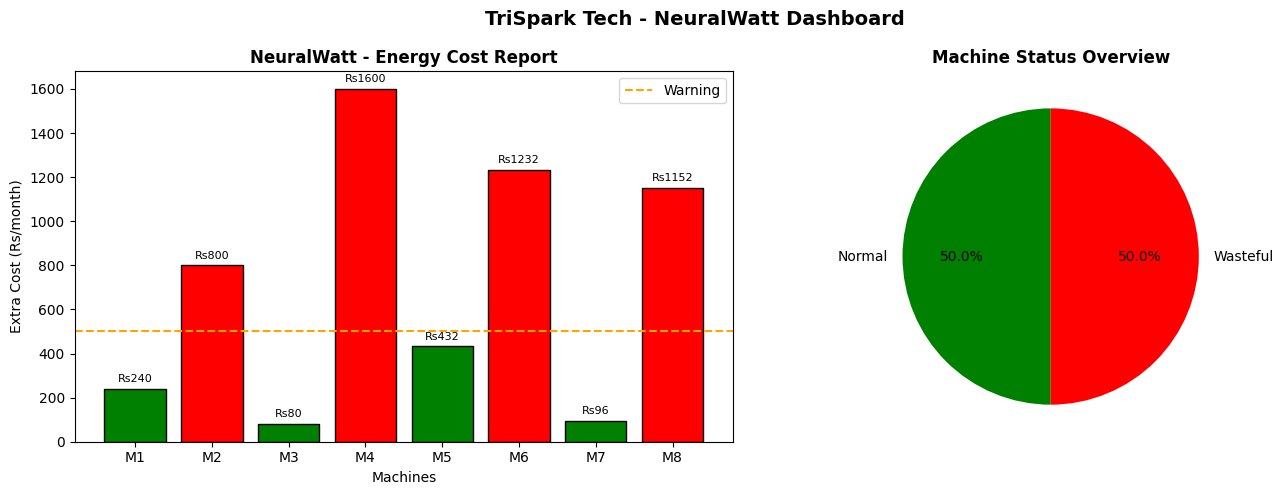

  NeuralWatt Energy Report
  TriSpark Tech
Machine M1: NORMAL | Rs240/month
Machine M2: WASTEFUL | Rs800/month
Machine M3: NORMAL | Rs80/month
Machine M4: WASTEFUL | Rs1600/month
Machine M5: NORMAL | Rs432/month
Machine M6: WASTEFUL | Rs1232/month
Machine M7: NORMAL | Rs96/month
Machine M8: WASTEFUL | Rs1152/month

Total Waste    : Rs4784.00/month
Model Accuracy : 100.00%
NeuralWatt Ready - TriSpark Tech!


In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# DATA
data = {
    'machine':       ['M1','M2','M3','M4','M5','M6','M7','M8'],
    'runtime_hours': [8,12,6,14,10,16,7,13],
    'power_rating':  [150,200,100,250,180,220,120,240],
    'temperature':   [45,78,40,90,60,85,42,88],
    'idle_time':     [2,5,1,8,3,7,1,6],
    'status':        [0,1,0,1,0,1,0,1]
}
df = pd.DataFrame(data)

# ML MODEL
X = df[['runtime_hours','power_rating','temperature','idle_time']]
y = df['status']
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
accuracy = accuracy_score(y_test,model.predict(X_test))

# PREDICT
costs,statuses = [],[]
for i,row in df.iterrows():
    test = pd.DataFrame({
        'runtime_hours':[row['runtime_hours']],
        'power_rating':[row['power_rating']],
        'temperature':[row['temperature']],
        'idle_time':[row['idle_time']]
    })
    pred = model.predict(test)[0]
    costs.append(row['idle_time']*row['power_rating']*0.8)
    statuses.append("Wasteful" if pred==1 else "Normal")

# GRAPHS
colors = ['green' if s=='Normal' else 'red' for s in statuses]
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Bar Chart
axes[0].bar(df['machine'],costs,color=colors,edgecolor='black')
axes[0].set_title('NeuralWatt - Energy Cost Report',fontweight='bold')
axes[0].set_xlabel('Machines')
axes[0].set_ylabel('Extra Cost (Rs/month)')
axes[0].axhline(y=500,color='orange',linestyle='--',label='Warning')
for i,cost in enumerate(costs):
    axes[0].text(i,cost+30,f'Rs{cost:.0f}',ha='center',fontsize=8)
axes[0].legend()

# Pie Chart
axes[1].pie(
    [statuses.count('Normal'),statuses.count('Wasteful')],
    labels=['Normal','Wasteful'],
    colors=['green','red'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Machine Status Overview',fontweight='bold')

plt.suptitle('TriSpark Tech - NeuralWatt Dashboard',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

# REPORT
print("="*40)
print("  NeuralWatt Energy Report")
print("  TriSpark Tech")
print("="*40)
for i,row in df.iterrows():
    status = "WASTEFUL" if statuses[i]==("Wasteful") else "NORMAL"
    print(f"Machine {row['machine']}: {status} | Rs{costs[i]:.0f}/month")
total = sum([c for c,s in zip(costs,statuses) if s=='Wasteful'])
print(f"\nTotal Waste    : Rs{total:.2f}/month")
print(f"Model Accuracy : {accuracy*100:.2f}%")
print("="*40)
print("NeuralWatt Ready - TriSpark Tech!")

In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

st.set_page_config(page_title="NeuralWatt", page_icon="⚡")

# DATA
data = {
    'machine':       ['M1','M2','M3','M4','M5','M6','M7','M8'],
    'runtime_hours': [8,12,6,14,10,16,7,13],
    'power_rating':  [150,200,100,250,180,220,120,240],
    'temperature':   [45,78,40,90,60,85,42,88],
    'idle_time':     [2,5,1,8,3,7,1,6],
    'status':        [0,1,0,1,0,1,0,1]
}
df = pd.DataFrame(data)

# ML MODEL
X = df[['runtime_hours','power_rating','temperature','idle_time']]
y = df['status']
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X,y)

# HEADER
st.title("⚡ NeuralWatt")
st.subheader("ML-Based Industrial Energy Optimizer")
st.markdown("**🏷️ TriSpark Tech**")
st.divider()

# METRICS
costs,statuses = [],[]
for i,row in df.iterrows():
    test = pd.DataFrame({
        'runtime_hours':[row['runtime_hours']],
        'power_rating':[row['power_rating']],
        'temperature':[row['temperature']],
        'idle_time':[row['idle_time']]
    })
    pred = model.predict(test)[0]
    costs.append(row['idle_time']*row['power_rating']*0.8)
    statuses.append("Wasteful" if pred==1 else "Normal")

total_waste = sum([c for c,s in zip(costs,statuses) if s=='Wasteful'])
normal = statuses.count('Normal')
wasteful = statuses.count('Wasteful')

col1,col2,col3 = st.columns(3)
col1.metric("Total Waste", f"Rs {total_waste:.0f}/month", "⚠️")
col2.metric("Normal Machines", f"{normal}/8", "✅")
col3.metric("Wasteful Machines", f"{wasteful}/8", "⚠️")
st.divider()

# BAR CHART
st.subheader("📊 Energy Cost per Machine")
colors = ['green' if s=='Normal' else 'red' for s in statuses]
fig,ax = plt.subplots(figsize=(10,4))
ax.bar(df['machine'],costs,color=colors,edgecolor='black')
ax.axhline(y=500,color='orange',linestyle='--',label='Warning')
for i,cost in enumerate(costs):
    ax.text(i,cost+30,f'Rs{cost:.0f}',ha='center',fontsize=8)
ax.legend()
st.pyplot(fig)

# TABLE
st.subheader("🏭 Machine Status Table")
df['Cost(Rs/month)'] = costs
df['Status'] = statuses
st.dataframe(df[['machine','temperature',
                  'idle_time','Cost(Rs/month)','Status']],
             use_container_width=True)

# PREDICT NEW
st.divider()
st.subheader("🔍 Predict New Machine")
col1,col2 = st.columns(2)
runtime = col1.slider("Runtime Hours",1,24,10)
power = col1.slider("Power Rating",50,300,150)
temp = col2.slider("Temperature",30,100,60)
idle = col2.slider("Idle Time",0,10,3)

if st.button("⚡ Predict!"):
    new = pd.DataFrame({
        'runtime_hours':[runtime],
        'power_rating':[power],
        'temperature':[temp],
        'idle_time':[idle]
    })
    pred = model.predict(new)[0]
    cost = idle * power * 0.8
    if pred == 1:
        st.error(f"⚠️ WASTEFUL! Extra Cost: Rs{cost:.0f}/month")
        st.warning("Fix: Reduce idle time & check temperature!")
    else:
        st.success(f"✅ NORMAL! Cost: Rs{cost:.0f}/month")

Overwriting app.py


In [11]:
!streamlit run app.py &
import time
time.sleep(5)
print("Streamlit Running! ✅")

/bin/bash: line 1: streamlit: command not found
Streamlit Running! ✅


In [12]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-1t64sbnznjao6-a.asia-east1-0.prod.colab.dev


In [13]:
!kill $(lsof -t -i:8501) 2>/dev/null
!streamlit run app.py --server.port=8501 &
import time
time.sleep(8)
print("Done! ✅")

/bin/bash: line 1: streamlit: command not found
Done! ✅


In [14]:
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"✅ Open this:")
print(url)

✅ Open this:
https://8501-m-s-1t64sbnznjao6-a.asia-east1-0.prod.colab.dev


In [15]:
# Save as HTML - No server needed!
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import base64
from io import BytesIO

# DATA & MODEL
data = {
    'machine':       ['M1','M2','M3','M4','M5','M6','M7','M8'],
    'runtime_hours': [8,12,6,14,10,16,7,13],
    'power_rating':  [150,200,100,250,180,220,120,240],
    'temperature':   [45,78,40,90,60,85,42,88],
    'idle_time':     [2,5,1,8,3,7,1,6],
    'status':        [0,1,0,1,0,1,0,1]
}
df = pd.DataFrame(data)
X = df[['runtime_hours','power_rating','temperature','idle_time']]
y = df['status']
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X,y)

costs,statuses = [],[]
for i,row in df.iterrows():
    test = pd.DataFrame({
        'runtime_hours':[row['runtime_hours']],
        'power_rating':[row['power_rating']],
        'temperature':[row['temperature']],
        'idle_time':[row['idle_time']]
    })
    pred = model.predict(test)[0]
    costs.append(row['idle_time']*row['power_rating']*0.8)
    statuses.append("Wasteful" if pred==1 else "Normal")

# GRAPH
colors = ['green' if s=='Normal' else 'red' for s in statuses]
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(df['machine'],costs,color=colors,edgecolor='black')
axes[0].set_title('Energy Cost per Machine')
axes[0].set_xlabel('Machines')
axes[0].set_ylabel('Rs/month')
axes[0].axhline(y=500,color='orange',linestyle='--',label='Warning')
for i,cost in enumerate(costs):
    axes[0].text(i,cost+30,f'Rs{cost:.0f}',ha='center',fontsize=8)
axes[0].legend()
axes[1].pie(
    [statuses.count('Normal'),statuses.count('Wasteful')],
    labels=['Normal','Wasteful'],
    colors=['green','red'],
    autopct='%1.1f%%'
)
axes[1].set_title('Machine Status')
plt.tight_layout()

# Save graph as base64
buf = BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode()

# Total
total = sum([c for c,s in zip(costs,statuses) if s=='Wasteful'])
normal = statuses.count('Normal')
wasteful = statuses.count('Wasteful')

# HTML
rows = ""
for i,row in df.iterrows():
    color = "#ff4444" if statuses[i]=="Wasteful" else "#44bb44"
    rows += f"""
    <tr>
        <td>{row['machine']}</td>
        <td>{row['temperature']}°C</td>
        <td>{row['idle_time']} hrs</td>
        <td>Rs{costs[i]:.0f}</td>
        <td style='color:{color};font-weight:bold'>{statuses[i]}</td>
    </tr>"""

html = f"""
<!DOCTYPE html>
<html>
<head>
    <title>NeuralWatt - TriSpark Tech</title>
    <style>
        body {{ font-family: Arial; background: #0a0a1a; color: white; padding: 20px; }}
        h1 {{ color: #00ffff; text-align: center; }}
        h2 {{ color: #ffff00; text-align: center; }}
        .metrics {{ display: flex; justify-content: center; gap: 30px; margin: 20px; }}
        .card {{ background: #1a1a2e; padding: 20px; border-radius: 10px; text-align: center; border: 1px solid #00ffff; }}
        .card h3 {{ color: #00ffff; margin: 0; font-size: 2em; }}
        .card p {{ color: #aaa; margin: 5px 0 0; }}
        table {{ width: 80%; margin: 20px auto; border-collapse: collapse; }}
        th {{ background: #1a1a2e; color: #00ffff; padding: 10px; }}
        td {{ padding: 10px; text-align: center; border-bottom: 1px solid #333; }}
        img {{ display: block; margin: 20px auto; border-radius: 10px; max-width: 90%; }}
    </style>
</head>
<body>
    <h1>⚡ NeuralWatt</h1>
    <h2>ML-Based Industrial Energy Optimizer</h2>
    <p style='text-align:center;color:#aaa'>TriSpark Tech</p>

    <div class='metrics'>
        <div class='card'>
            <h3>Rs{total:.0f}</h3>
            <p>Total Waste/month</p>
        </div>
        <div class='card'>
            <h3 style='color:green'>{normal}/8</h3>
            <p>Normal Machines</p>
        </div>
        <div class='card'>
            <h3 style='color:red'>{wasteful}/8</h3>
            <p>Wasteful Machines</p>
        </div>
    </div>

    <img src='data:image/png;base64,{img_base64}'/>

    <table>
        <tr>
            <th>Machine</th>
            <th>Temperature</th>
            <th>Idle Time</th>
            <th>Cost/month</th>
            <th>Status</th>
        </tr>
        {rows}
    </table>
</body>
</html>"""

with open('neurwatt.html','w') as f:
    f.write(html)

print("✅ Dashboard Ready!")
print("Download neurwatt.html and open in browser!")

from google.colab import files
files.download('neurwatt.html')

✅ Dashboard Ready!
Download neurwatt.html and open in browser!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>